In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid, simpson, cumulative_trapezoid

# Apendice (Sesión 03)

<img src="figures/LogoCinvestav.png" style="height:100px" title="Cinvestav">

**CINVESTAV Unidad Saltillo**

**Programa de Maestría en Ciencias en Ingeniería Metalúrgica**

Dr. Edgar Ivan Castro Cedeño


2025

Contacto:
[edgar.castro@cinvestav.mx](mailto:edgar.castro@cinvestav.mx)

# Ejemplos de implementación

## Comparación de un reactor PFR vs un arreglo de CSTR en serie

In [3]:
def rAo1(k, C0, X):
    return -k*C0*(1-X)

In [4]:
# Entrada
FA0 = 1 # [mol.s-1]
k = 10
c0 = 1
X = np.linspace(0, 0.8, 50)

rA = rAo1(k, c0, X)

# Creación de DataFrame con datos de interés
df = pd.DataFrame({"X": X, '-rA': -rA})
df['1/-rA'] = 1/df['-rA'] # [(mol-1.m3).s]
df['F/-rA'] = FA0 * df['1/-rA'] # [m3]

display(df)

,X,-rA,1/-rA,F/-rA
0,0.000000,10.000000,0.100000,0.100000
1,0.016327,9.836735,0.101660,0.101660
2,0.032653,9.673469,0.103376,0.103376
3,0.048980,9.510204,0.105150,0.105150
4,0.065306,9.346939,0.106987,0.106987
5,0.081633,9.183673,0.108889,0.108889
6,0.097959,9.020408,0.110860,0.110860
7,0.114286,8.857143,0.112903,0.112903
8,0.130612,8.693878,0.115023,0.115023
9,0.146939,8.530612,0.117225,0.117225


Cumulative conversions after each CSTR:
After CSTR 1: 0.8333
After CSTR 2: 0.8565
After CSTR 3: 0.8736
After CSTR 4: 0.8870
After CSTR 5: 0.8976
After CSTR 6: 0.9063
After CSTR 7: 0.9136
After CSTR 8: 0.9199
After CSTR 9: 0.9252
After CSTR 10: 0.9299

Overall conversion in PFR: 0.8647


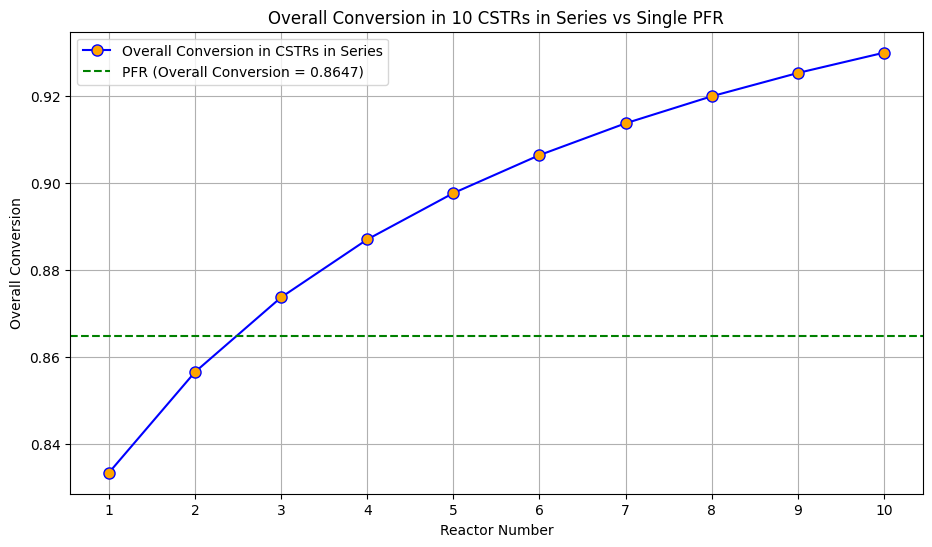

In [7]:
# Parameters
k = 1     # Reaction rate constant (1/min)
V_total = 10.0  # Total volume of the reactors (L)
Q = 5.0        # Volumetric flow rate (L/min)
C_in = 10.0    # Initial concentration of A (mol/L)

# Number of CSTRs in series
num_cstrs = 10
V_cstr = V_total / num_cstrs  # Volume of each CSTR

# CSTR Calculations for Cumulative Conversion
X_cstr_cumulative = np.zeros(num_cstrs + 1)  # Cumulative conversion after each CSTR
X_cstr_cumulative[0] = 0  # Initial cumulative conversion (no reaction has occurred)

for i in range(1, num_cstrs + 1):
    # Conversion in the current CSTR step
    X_i = (1 - X_cstr_cumulative[i-1]) / (1 + k * V_cstr / Q)
    # Update cumulative conversion
    X_cstr_cumulative[i] = X_cstr_cumulative[i-1] + X_i * (1 - X_cstr_cumulative[i-1])

# PFR Calculation for Overall Conversion
X_pfr = 1 - np.exp(-k * V_total / Q)

# Display conversions
print(f"Cumulative conversions after each CSTR:")
for i in range(1, num_cstrs + 1):
    print(f"After CSTR {i}: {X_cstr_cumulative[i]:.4f}")

print(f"\nOverall conversion in PFR: {X_pfr:.4f}")

# Plotting
plt.figure(figsize=(11, 6))
cstr_indices = np.arange(1, num_cstrs + 1)

# Plot cumulative conversion for CSTRs in series
plt.plot(cstr_indices, X_cstr_cumulative[1:], 'o-', label='Overall Conversion in CSTRs in Series', color='blue', markerfacecolor='orange', markersize=8)

# Plot single PFR conversion
plt.axhline(y=X_pfr, color='green', linestyle='--', label=f'PFR (Overall Conversion = {X_pfr:.4f})')

# Plot formatting
plt.xlabel('Reactor Number')
plt.ylabel('Overall Conversion')
plt.title(f'Overall Conversion in {num_cstrs} CSTRs in Series vs Single PFR')
plt.xticks(cstr_indices)
plt.grid(True)
plt.legend()
plt.show()

# Referencias

- ***[Fogler, 2016]***: Fogler, H. S. (2016) Elements of Chemical Reaction Engineering (5th ed.). Prentice Education Inc.